# 1. Synthetic Balanced Training Data â€” Generation

**Pair:** Run this notebook first, then run `2_balanced_training.ipynb` to retrain models.

NCAA tournament upsets (seed diff â‰¥ 5, lower-ranked team wins) are significantly underrepresented  
in historical training data. This notebook:
1. Analyzes upset/non-upset imbalance in training data (2010â€“2023), split by Men's and Women's
2. Analyzes upset patterns statistically to guide synthesis
3. Generates synthetic upset records via Gaussian perturbation of real upset games
4. Creates balanced 50/50 datasets and saves them for use in notebook 2

**Outputs:**
- `data_2026/final_features_balanced_M.csv` â€” Men's balanced training data
- `data_2026/final_features_balanced_W.csv` â€” Women's balanced training data

**Upset definition:** seed_diff â‰¥ 5 AND the lower-seeded (higher seed number) team wins.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.simplefilter(action='ignore', category=UserWarning)
rng = np.random.default_rng(42)

UPSET_SEED_DIFF  = 5     # seed diff threshold to qualify as an upset
TRAIN_MIN_SEASON = 2010
TRAIN_MAX_SEASON = 2023
PERTURBATION_SCALE = 0.25  # fraction of feature std used for Gaussian noise

NON_FEATURE_COLS = {'SEASON', 'WIN_INDICATOR', 'L_TEAMID', 'W_TEAMID',
                    'W_SCORE', 'L_SCORE', 'ROUND', 'L_REGION', 'W_REGION'}

print('Setup complete.')

Setup complete.


## Load and Prepare Training Data

In [2]:
def load_and_prep(path):
    """Load features CSV, rename score cols, add WIN_INDICATOR=1 (W always wins in CSV)."""
    df = (
        pd.read_csv(path)
        .rename(columns={
            'WTEAMID': 'W_TEAMID', 'LTEAMID': 'L_TEAMID',
            'WSCORE':  'W_SCORE',  'LSCORE':  'L_SCORE',
        })
    )
    drop_cols = ['W_CTWINS', 'W_AVERAGECTSCORE', 'L_CTWINS', 'L_AVERAGECTSCORE',
                 'W_WLOCN', 'W_WLOCH', 'W_WLOCA', 'L_WLOCN', 'L_WLOCH', 'L_WLOCA']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df['WIN_INDICATOR'] = 1  # original CSV: W team is always the winner
    return df


full_m = load_and_prep('data_2026/final_features.csv')
full_w = load_and_prep('data_2026/final_features_W.csv')

train_m = full_m[(full_m.SEASON >= TRAIN_MIN_SEASON) & (full_m.SEASON <= TRAIN_MAX_SEASON)].copy()
train_w = full_w[(full_w.SEASON >= TRAIN_MIN_SEASON) & (full_w.SEASON <= TRAIN_MAX_SEASON)].copy()

feature_cols_m = [c for c in train_m.columns if c not in NON_FEATURE_COLS]
feature_cols_w = [c for c in train_w.columns if c not in NON_FEATURE_COLS]

print(f"Men's   training seasons: {sorted(train_m.SEASON.unique())}")
print(f"Women's training seasons: {sorted(train_w.SEASON.unique())}")
print(f"Men's features: {len(feature_cols_m)} | Women's features: {len(feature_cols_w)}")

Men's   training seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Women's training seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Men's features: 164 | Women's features: 157


C:\Users\joebu\AppData\Local\Temp\ipykernel_50784\3725119849.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['WIN_INDICATOR'] = 1  # original CSV: W team is always the winner


## Flag Upsets

In the original CSV the W team always wins, so `W_SEED > L_SEED` means the lower-ranked team (higher seed number) won â€” that's an upset.

In [3]:
def flag_upsets(df):
    df = df.copy()
    df['SEED_DIFF']   = df['W_SEED'] - df['L_SEED']
    df['IS_ELIGIBLE'] = df['SEED_DIFF'].abs() >= UPSET_SEED_DIFF
    df['IS_UPSET']    = df['IS_ELIGIBLE'] & (df['SEED_DIFF'] >= UPSET_SEED_DIFF)
    return df


train_m = flag_upsets(train_m)
train_w = flag_upsets(train_w)

round_names = {0: 'Play-In', 1: 'R64', 2: 'R32', 3: 'S16', 4: 'E8', 5: 'FF', 6: 'Champ'}

for df, label in [(train_m, "Men's"), (train_w, "Women's")]:
    total  = len(df)
    n_up   = df['IS_UPSET'].sum()
    n_elig = df['IS_ELIGIBLE'].sum()
    print(f"{label}: {total} games | {n_up} upsets ({100*n_up/total:.1f}%) "
          f"| eligible: {n_elig} | upset rate when eligible: {100*n_up/n_elig:.1f}%")
    print(f"  Non-upsets: {total - n_up} | Upsets: {n_up} | Imbalance ratio: {(total-n_up)/n_up:.1f}:1")
    print()

Men's: 854 games | 130 upsets (15.2%) | eligible: 507 | upset rate when eligible: 25.6%
  Non-upsets: 724 | Upsets: 130 | Imbalance ratio: 5.6:1

Women's: 781 games | 59 upsets (7.6%) | eligible: 450 | upset rate when eligible: 13.1%
  Non-upsets: 722 | Upsets: 59 | Imbalance ratio: 12.2:1



## Visualize Upset Imbalance by Round

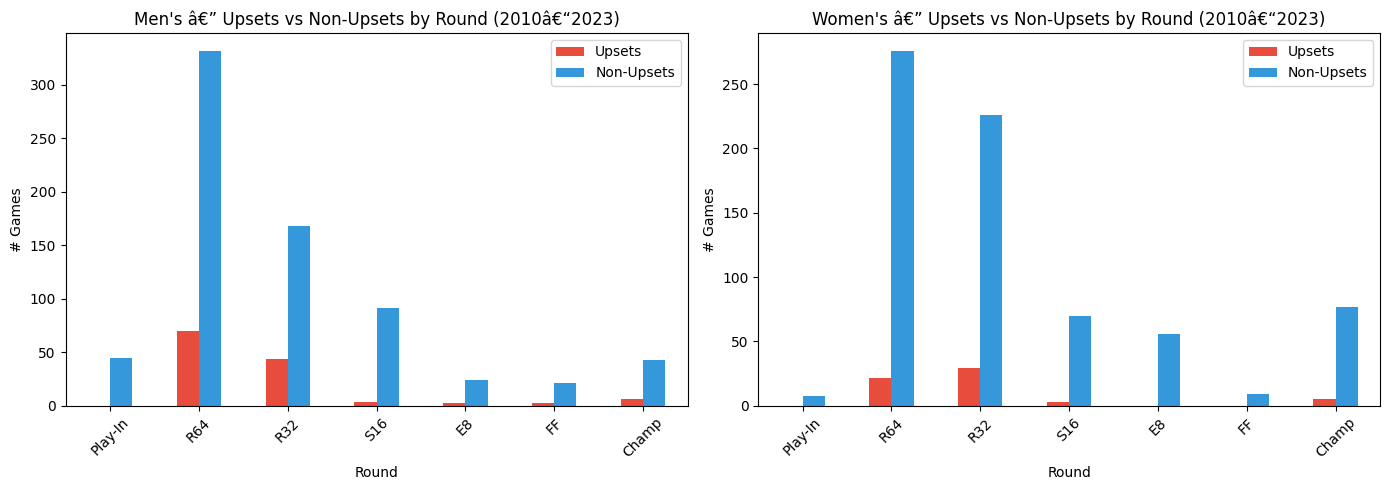

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [(axes[0], train_m, "Men's"), (axes[1], train_w, "Women's")]:
    rnd_data = []
    for r in sorted(df.ROUND.unique()):
        rdf = df[df.ROUND == r]
        rnd_data.append({'Round': round_names.get(r, f'R{r}'),
                         'Upsets': rdf['IS_UPSET'].sum(),
                         'Non-Upsets': (~rdf['IS_UPSET']).sum()})
    rnd_df = pd.DataFrame(rnd_data).set_index('Round')
    rnd_df[['Upsets', 'Non-Upsets']].plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'])
    ax.set_title(f'{title} â€” Upsets vs Non-Upsets by Round (2010â€“2023)', fontsize=12)
    ax.set_xlabel('Round'); ax.set_ylabel('# Games')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The bar charts confirm upsets are concentrated in the early rounds (R64, R32) where large seed mismatches are common. Women's tournaments show far fewer upsets across every round.

## Analyze Upset Patterns & Guide Synthesis

Compute the top differentiating features between upsets and non-upsets to understand what makes an upset and to validate the perturbation approach.

In [5]:
def analyze_upset_patterns(df, feature_cols, label, n_top=15):
    """Print the top features separating upsets from non-upsets with effect sizes."""
    upsets  = df[df['IS_UPSET'] == True]
    non_ups = df[df['IS_UPSET'] == False]

    # Exclude one-hot conference columns for cleaner output
    key_feats = [c for c in feature_cols
                 if not any(c.startswith(p) for p in ['W_CONF_', 'L_CONF_'])]

    rows = []
    for col in key_feats:
        u_vals  = upsets[col].dropna()
        n_vals  = non_ups[col].dropna()
        if len(u_vals) < 5 or u_vals.std() == 0:
            continue
        diff    = u_vals.mean() - n_vals.mean()
        pooled  = np.sqrt((u_vals.std()**2 + n_vals.std()**2) / 2)
        cohen_d = diff / pooled if pooled > 0 else 0
        rows.append({
            'Feature':    col,
            'Upset Mean': round(u_vals.mean(), 3),
            'Non-Up Mean':round(n_vals.mean(), 3),
            'Diff':       round(diff, 3),
            "Cohen's d":  round(cohen_d, 3),
            'Upset Std':  round(u_vals.std(), 3),
        })

    result = (pd.DataFrame(rows)
                .sort_values("Cohen's d", key=abs, ascending=False)
                .head(n_top)
                .reset_index(drop=True))

    print(f"\n{'='*70}")
    print(f"{label} â€” Top {n_top} Features Differentiating Upsets from Non-Upsets")
    print(f"{'='*70}")
    print(result.to_string(index=False))
    print(f"\nSeed diff stats (upset games):")
    print(f"  Mean: {upsets['SEED_DIFF'].mean():.2f} | Std: {upsets['SEED_DIFF'].std():.2f} "
          f"| Min: {upsets['SEED_DIFF'].min()} | Max: {upsets['SEED_DIFF'].max()}")
    print(f"\nPerturbation scale of {PERTURBATION_SCALE}Ã—std keeps synthetic records within "
          f"~Â±{PERTURBATION_SCALE:.0%} of the upset population spread â€” "
          f"tight enough for realism, diverse enough to add signal.")
    return result


summary_m = analyze_upset_patterns(train_m, feature_cols_m, "Men's")
summary_w = analyze_upset_patterns(train_w, feature_cols_w, "Women's")


Men's â€” Top 15 Features Differentiating Upsets from Non-Upsets
          Feature  Upset Mean  Non-Up Mean   Diff  Cohen's d  Upset Std
           W_SEED      11.231        4.682  6.548      2.143      2.267
           L_SEED       3.715        9.848 -6.133     -1.847      1.805
     W_TOTAL_WINS      22.169       25.098 -2.929     -0.814      3.509
  W_WINMARGINMEAN      13.691       15.823 -2.132     -0.703      2.743
     L_TOTAL_WINS      24.823       22.587  2.236      0.638      3.338
     W_SCORE_MEAN      73.165       75.619 -2.454     -0.522      4.365
 L_WON_CONFERENCE       0.254        0.493 -0.239     -0.509      0.437
W_WINMARGINMEDIAN      11.942       13.666 -1.723     -0.504      3.145
       W_FGM_MEAN      25.814       26.772 -0.959     -0.499      1.726
       L_AST_MEAN      14.904       14.069  0.836      0.460      1.836
     W_FGM_STDDEV       4.443        4.749 -0.306     -0.453      0.628
     W_AST_STDDEV       4.152        4.443 -0.291     -0.445      0.59

In [6]:
# Split into upsets / non-upsets for synthesis
upsets_m  = train_m[train_m['IS_UPSET'] == True].copy()
non_ups_m = train_m[train_m['IS_UPSET'] == False].copy()
upsets_w  = train_w[train_w['IS_UPSET'] == True].copy()
non_ups_w = train_w[train_w['IS_UPSET'] == False].copy()

print(f"Men's   â€” upsets: {len(upsets_m):,} | non-upsets: {len(non_ups_m):,} | need {len(non_ups_m)-len(upsets_m):,} synthetic")
print(f"Women's â€” upsets: {len(upsets_w):,} | non-upsets: {len(non_ups_w):,} | need {len(non_ups_w)-len(upsets_w):,} synthetic")

Men's   â€” upsets: 130 | non-upsets: 724 | need 594 synthetic
Women's â€” upsets: 59 | non-upsets: 722 | need 663 synthetic


## Generate Synthetic Upset Records

In [7]:
def generate_synthetic_upsets(upsets_df, n_needed, feature_cols, rng, scale=PERTURBATION_SCALE):
    """
    Gaussian perturbation of real upset records to produce synthetic ones.

    Rules:
    - Binary (0/1) features: copied verbatim from seed record
    - Numeric features: seed value + N(0, scale * std)
    - Seeds: small integer jitter, enforce W_SEED - L_SEED >= UPSET_SEED_DIFF
    - Score/count/margin features: clipped to >= 0
    - WIN_INDICATOR: always 1 (upset winner wins)
    """
    if len(upsets_df) == 0 or n_needed <= 0:
        return pd.DataFrame()

    # Split feature cols into binary vs numeric
    binary_cols  = [c for c in feature_cols
                    if set(upsets_df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    numeric_cols = [c for c in feature_cols
                    if c not in binary_cols and c not in ('W_SEED', 'L_SEED', 'SEED_DIFF')]

    # Feature stds over the upset population
    feat_stds = upsets_df[numeric_cols].std().fillna(0)

    # Positive-only feature keywords (cannot be negative)
    pos_kw = ('SCORE', 'MARGIN', 'FGM', 'FGA', 'FTM', 'FTA',
               'OR_', 'DR_', 'AST', 'TO_', 'STL', 'BLK', 'PF_', 'WINS', 'TOTAL')

    synthetic_rows = []
    seed_indices   = rng.integers(0, len(upsets_df), size=n_needed)

    for idx in seed_indices:
        base = upsets_df.iloc[idx].copy()
        row  = base.copy()

        # Perturb numeric features
        for col in numeric_cols:
            noise = rng.normal(0, scale * float(feat_stds[col]))
            val   = float(base[col]) + noise
            if any(kw in col for kw in pos_kw):
                val = max(0.0, val)
            row[col] = val

        # Seeds: small integer jitter, enforce upset gap
        w_s = int(np.clip(int(base['W_SEED']) + rng.integers(-1, 2), 1, 16))
        l_s = int(np.clip(int(base['L_SEED']) + rng.integers(-1, 2), 1, 16))
        if w_s - l_s < UPSET_SEED_DIFF:
            w_s = min(16, l_s + UPSET_SEED_DIFF)
        row['W_SEED'] = w_s
        row['L_SEED'] = l_s
        if 'SEED_DIFF' in row.index:
            row['SEED_DIFF'] = w_s - l_s

        row['WIN_INDICATOR'] = 1
        synthetic_rows.append(row)

    return pd.DataFrame(synthetic_rows)


print('Synthetic generation function defined.')

Synthetic generation function defined.


In [8]:
def balance_dataset(upsets_df, non_ups_df, feature_cols, rng, label):
    """
    Balance upsets to match non-upsets via synthetic oversampling.
    Returns the combined dataset with IS_SYNTHETIC column.
    """
    n_need = max(0, len(non_ups_df) - len(upsets_df))
    print(f'[{label}] Non-upsets: {len(non_ups_df):,} | Real upsets: {len(upsets_df):,} '
          f'| Synthetic needed: {n_need:,}')

    synthetic = generate_synthetic_upsets(upsets_df, n_need, feature_cols, rng)

    upsets_df   = upsets_df.copy();   upsets_df['IS_SYNTHETIC']   = False
    non_ups_df  = non_ups_df.copy();  non_ups_df['IS_SYNTHETIC']  = False
    if len(synthetic) > 0:
        synthetic['IS_SYNTHETIC'] = True

    balanced = pd.concat([non_ups_df, upsets_df, synthetic], ignore_index=True)
    n_total_ups = len(upsets_df) + len(synthetic)
    print(f'[{label}] Balanced total: {len(balanced):,} rows '
          f'({n_total_ups:,} upsets + {len(non_ups_df):,} non-upsets)')
    return balanced


balanced_m = balance_dataset(upsets_m, non_ups_m, feature_cols_m, rng, 'M')
balanced_w = balance_dataset(upsets_w, non_ups_w, feature_cols_w, rng, 'W')

[M] Non-upsets: 724 | Real upsets: 130 | Synthetic needed: 594
[M] Balanced total: 1,448 rows (724 upsets + 724 non-upsets)
[W] Non-upsets: 722 | Real upsets: 59 | Synthetic needed: 663
[W] Balanced total: 1,444 rows (722 upsets + 722 non-upsets)


## Validate Synthetic Record Quality

Compare synthetic upsets against real upsets using statistical tests (KS test + mean/std comparison) to confirm the synthetic records are statistically plausible.

In [9]:
def validate_synthetic(balanced_df, feature_cols, label, n_check=20):
    """
    KS test + mean/std comparison between real upsets and synthetic upsets.
    High KS p-value = distributions are similar (good).
    """
    synth   = balanced_df[balanced_df['IS_SYNTHETIC'] == True]
    real_up = balanced_df[(balanced_df['IS_SYNTHETIC'] == False) & (balanced_df['IS_UPSET'] == True)]

    if len(synth) == 0:
        print(f"[{label}] No synthetic records generated (already balanced).")
        return

    key_feats = [c for c in feature_cols
                 if not any(c.startswith(p) for p in ['W_CONF_', 'L_CONF_'])
                 and real_up[c].std() > 0][:n_check]

    rows = []
    for col in key_feats:
        r = real_up[col].dropna()
        s = synth[col].dropna()
        ks_stat, ks_p = stats.ks_2samp(r, s)
        rows.append({
            'Feature':     col,
            'Real Mean':   round(r.mean(), 3),
            'Synth Mean':  round(s.mean(), 3),
            'Real Std':    round(r.std(), 3),
            'Synth Std':   round(s.std(), 3),
            'KS p-value':  round(ks_p, 3),
            'Similar?':    'Yes' if ks_p > 0.05 else 'No',
        })

    vdf = pd.DataFrame(rows)
    pct_similar = 100 * (vdf['Similar?'] == 'Yes').mean()

    print(f"\n{'='*70}")
    print(f"{label} â€” Synthetic vs Real Upset Validation (n={len(synth):,} synthetic, n={len(real_up):,} real)")
    print(f"{'='*70}")
    print(vdf.to_string(index=False))
    print(f"\n{pct_similar:.0f}% of features pass KS test (p>0.05) â€” distributions are statistically similar.")

    # Quick seed check
    print(f"\nSeed sanity check on synthetic records:")
    print(f"  W_SEED range: {synth['W_SEED'].min():.0f}â€“{synth['W_SEED'].max():.0f}  "
          f"(real: {real_up['W_SEED'].min():.0f}â€“{real_up['W_SEED'].max():.0f})")
    print(f"  L_SEED range: {synth['L_SEED'].min():.0f}â€“{synth['L_SEED'].max():.0f}  "
          f"(real: {real_up['L_SEED'].min():.0f}â€“{real_up['L_SEED'].max():.0f})")
    if 'SEED_DIFF' in synth.columns:
        all_valid = (synth['SEED_DIFF'] >= UPSET_SEED_DIFF).all()
        print(f"  All SEED_DIFF >= {UPSET_SEED_DIFF}: {all_valid}")


validate_synthetic(balanced_m, feature_cols_m, "Men's")
validate_synthetic(balanced_w, feature_cols_w, "Women's")


Men's â€” Synthetic vs Real Upset Validation (n=594 synthetic, n=130 real)
       Feature  Real Mean  Synth Mean  Real Std  Synth Std  KS p-value Similar?
        W_SEED     11.231      11.281     2.267      2.324       0.510      Yes
        L_SEED      3.715       3.778     1.805      1.946       0.809      Yes
  W_SCORE_MEAN     73.165      72.996     4.365      4.284       0.945      Yes
W_SCORE_MEDIAN     73.158      73.052     4.523      4.626       0.545      Yes
W_SCORE_STDDEV     11.071      10.963     1.629      1.622       0.576      Yes
    W_FGM_MEAN     25.814      25.764     1.726      1.776       0.851      Yes
  W_FGM_MEDIAN     25.746      25.711     1.815      1.899       0.067      Yes
  W_FGM_STDDEV      4.443       4.419     0.628      0.631       0.972      Yes
    W_FGA_MEAN     56.680      56.600     2.903      3.076       0.910      Yes
  W_FGA_MEDIAN     56.485      56.368     3.090      3.138       0.459      Yes
  W_FGA_STDDEV      6.684       6.608     1.

## Apply W/L Augmentation to Balanced Data

In [10]:
def swap_wl(df):
    """Return a copy of df with all W_ and L_ columns swapped."""
    out = df.copy()
    w_cols = sorted([c for c in df.columns if c.startswith('W_')])
    for w in w_cols:
        l = 'L_' + w[2:]
        if l in df.columns:
            out[w] = df[l]
            out[l] = df[w]
    return out


def augment(df, label):
    swapped = swap_wl(df)
    aug = pd.concat([df, swapped], ignore_index=True)
    aug['WIN_INDICATOR'] = (aug['W_SCORE'] > aug['L_SCORE']).astype(int)
    print(f'[{label}] After augmentation: {len(aug):,} rows ')
    return aug


aug_m = augment(balanced_m, 'M')
aug_w = augment(balanced_w, 'W')

[M] After augmentation: 2,896 rows 
[W] After augmentation: 2,888 rows 


## Save Balanced Datasets

In [11]:
aug_m.to_csv('data_2026/final_features_balanced_M.csv', index=False)
aug_w.to_csv('data_2026/final_features_balanced_W.csv', index=False)

print(f"Saved Men's   balanced data: {len(aug_m):,} rows -> data_2026/final_features_balanced_M.csv")
print(f"Saved Women's balanced data: {len(aug_w):,} rows -> data_2026/final_features_balanced_W.csv")
print()
print('Run 2_balanced_training.ipynb to retrain per-round models on the balanced data.')

Saved Men's   balanced data: 2,896 rows -> data_2026/final_features_balanced_M.csv
Saved Women's balanced data: 2,888 rows -> data_2026/final_features_balanced_W.csv

Run 2_balanced_training.ipynb to retrain per-round models on the balanced data.
